In [1]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Getting Route data from OSRM

base_url = "http://router.project-osrm.org/route/v1/driving/"

sasolburg_coords = 27.8333,-26.8167 # Coords should be (long,lat)
zeerust_coords = 26.083,-25.533

coords = f'{sasolburg_coords[0]},{sasolburg_coords[1]};{zeerust_coords[0]},{zeerust_coords[1]}'
params = {
    "steps": "false",
    "geometries": "geojson",
    "overview": "full"
}

response = requests.get(f"{base_url}{coords}", params=params)
data = response.json()

if data.get('code') == 'Ok':
    route = data['routes'][0]
    print(f"Distance: {route['distance']} meters")
    print(f"Duration: {(route['duration']/3600):.2f} hours")
else:
    print("Error:", data.get('code'))

Distance: 334001.4 meters
Duration: 4.19 hours


In [3]:
print(route.keys())

dict_keys(['legs', 'weight_name', 'geometry', 'weight', 'duration', 'distance'])


In [4]:
print('Number of route plot points: ',len(route['geometry']['coordinates']))
print(f"Average distance per plot point: {(route['distance'])/(len(route['geometry']['coordinates'])): .2f} metres")

Number of route plot points:  3411
Average distance per plot point:  97.92 metres


In [5]:
# Clearly a resolution of about a 100 metres per plot point along our route is valid

path = route['geometry']['coordinates']
for i in path: i[0],i[1] = i[1],i[0] # Switching to long,lat to lat,long

In [6]:
# Getting elevation of each point in path

import srtm

elevation_data = srtm.get_data()

for point in path: 
    lat,long = point[0],point[1]
    elevation = elevation_data.get_elevation(lat,long)
    point.append(float(elevation))
print(path[0])

[-26.816578, 27.833327, 1492.0]


In [7]:
# Defining Haersine function to calculate distance between two points

import math

def haversine(lat1, lon1, lat2, lon2):
    # Earth radius in kilometers (approximate)
    R = 6371.0

    # Convert degrees to radians
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)

    # Apply formula
    a = math.sin(dphi / 2)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    return R * c * 1000 #m

In [8]:
# Finding and recording slope between successive points

for i in range(len(path)-1):
    dh = path[i+1][2] - path[i][2]
    dl = haversine(path[i+1][0],path[i+1][1],path[i][0],path[i][1])
    slope = dh/dl
    theta = np.arctan(slope)
    path[i].append(theta)
path[-1].append(0.0) # Adding this artificially to the last point for the sake of dimensionality
print(path[0],path[1],path[-1])

[-26.816578, 27.833327, 1492.0, np.float64(0.0)] [-26.816557, 27.833208, 1492.0, np.float64(0.0)] [-25.532847, 26.083409, 1250.0, 0.0]


In [9]:
df = pd.DataFrame(path,columns=['Latitude','Longitude','Elevation','Slope Angle'])
df.to_csv('path.csv',index=False)

print('='*50); print('\n')
print("                    CSV MADE"); print('\n')
print('='*50); print('\n')




                    CSV MADE






In [10]:
# Building a function that gives us Solar Irradiance depending on the time of day

def P_solar(t):

    mean = 12*3600 # mid-day
    sigma = 11600 #s
    irr_max = 1073
    eta = 0.24
    area = 6

    irradiance = (irr_max)*(np.exp(-0.5 * ((t - mean) / sigma)**2))
    power = irradiance*eta*area

    return power


In [11]:
# Defining the physics terms

k = 0.09
eta_motor = 0.9
eta_regen = 0.7
m = 300 
g = 9.81
mu = 0.007
capacity_Wh = 3100

def P_drag(v):
    return k*(v**3)

def P_gravity(v,theta):
    return (m*g*v*np.sin(theta))

def P_rolling(v,theta):
    return (m*g*v*np.cos(theta)*mu)

def P_mech(v,theta):
    return P_drag(v) + P_gravity(v,theta) + P_rolling(v,theta)

def P_regen(v,theta):
    return (eta_regen*(P_mech(v,theta)))

def P_battery(v,theta,t):
    P_losses = 100
    P_electrical = np.where(P_mech(v,theta) >= 0, P_mech(v,theta) / eta_motor, P_mech(v,theta) * eta_regen)
    return P_electrical + P_losses - P_solar(t)

def new_SoC(SoC,v,theta,t,dt,capacity_Wh):
    delta_energy = P_battery(v,theta,t) * dt  # in Watt-seconds
    delta_energy_Wh = delta_energy / 3600
    return SoC - (delta_energy_Wh / capacity_Wh) # SoC is a %


In [12]:
print('='*50); print('\n\tBUILDING THE OPTIMIZERS\n'); print('='*50)


	BUILDING THE OPTIMIZERS



In [13]:
df = pd.read_csv("path.csv")

theta = df['Slope Angle'].values
lat1 = df['Latitude']
lon1 = df['Longitude']
lat2 = df['Latitude'].shift(-1)
lon2 = df['Longitude'].shift(-1)
ds = [haversine(lt1, ln1, lt2, ln2) if not pd.isna(lt2) else 0.0 for lt1, ln1, lt2, ln2 in zip(lat1, lon1, lat2, lon2)]
ds = np.array(ds)

def simulate(v,SoC=1.0): # Returns SoC and time taken to get from Sol to Zeerust for a certain velocity profile(np.array-v)
    
    simulation_ran = True
    min_SoC = 2.0
    
    dt = ds/v
    T_total = np.sum(dt)
    t_cumulative = np.cumsum(dt)

    for i in range(len(v)):
        SoC = new_SoC(SoC,v[i],theta[i],(8*3600+t_cumulative[i]),dt[i],capacity_Wh)
        if SoC < 0.2: simulation_ran = False
        if SoC < min_SoC: min_SoC = SoC

    return SoC,T_total,simulation_ran,min_SoC
    


In [14]:
v_test = np.full(len(ds), 80/3.6)  
final_soc, total_time, success, min_SoC = simulate(v_test)
print(f"Final SOC: {final_soc:.2%}, Time: {total_time/3600:.2f} hrs, Success: {success}, Minimum SoC: {min_SoC: .2f}")

Final SOC: 24.75%, Time: 4.18 hrs, Success: True, Minimum SoC:  0.25


In [15]:
from scipy.optimize import minimize
from scipy.interpolate import interp1d

NUM_NODES = 3411//2
node_indices = np.linspace(0, len(ds) - 1, NUM_NODES, dtype=int)
node_distances = np.cumsum(ds)[node_indices]          # cumulative distance at each node
full_distances = np.cumsum(ds)                         # cumulative distance at every point

def interpolate_velocity(v_coarse):
    
    interp_fn = interp1d(node_distances, v_coarse, kind='linear',
                         fill_value='extrapolate')
    return interp_fn(full_distances)


def objective_sol2zeerust(v,*args): # Calculates loss for a velocity profile. 
    
    ds,theta,start_SoC,Q_time,Q_SoC,R_control = args

    v_full = interpolate_velocity(v)                   # upsample before simulating
    SoC_final, t_final, _, min_SoC = simulate(v_full, start_SoC)

    t_norm = 9*3600 # Race duration is 9 hrs, we'll use this to normalize time and SoC in the loss function
    cost_time = Q_time*((t_final/t_norm)**2)
    cost_SoC = Q_SoC*((1.0-SoC_final)**2)
    
    dv = np.diff(v)
    cost_control = R_control * np.sum(dv**2)

    J = cost_time + cost_SoC+ cost_control
    return J

def soc_constraint(v,*args): # Fed into the SLSQP to constraint SoC
    
    ds,theta,start_SoC = args[:3]
    v_full = interpolate_velocity(v)                   # upsample before simulating
    SoC_final, t_final, _, min_SoC = simulate(v_full, start_SoC)
    
    # The lowest point in the entire battery profile must remain above 0.20
    return min_SoC-0.20

def optimize_phase1(ds,theta,initial_soc,num_nodes):    
    
    Q_time = 10.0      
    Q_soc = 1.0       
    R_control = 0.5   
     
    v_guess = np.full(num_nodes, 20.0) # ~72 kmph
        
    V_MIN, V_MAX = 60.0/(3.6), 100.0/(3.6) # m/s
    bounds = [(V_MIN, V_MAX) for _ in range(num_nodes)]
    
    cons = {
        'type': 'ineq', 
        'fun': soc_constraint, 
        'args': (ds,theta,initial_soc)
    }
    
    solution = minimize(
        objective_sol2zeerust, 
        v_guess, 
        args=(ds, theta, initial_soc, Q_time, Q_soc, R_control),
        method='SLSQP',
        bounds=bounds,
        constraints=cons,
        options={'maxiter': 300, 'ftol': 1e-4, 'disp': True}
    )
    
    if solution.success:
        optimal_v = solution.x
        return optimal_v, solution.fun
    else:
        print("WARNING: Optimizer failed to converge.", solution.message)
        return np.full(len(ds), 15.0), None

In [16]:
optimal_v_coarse, _ = optimize_phase1(ds, theta, 1.0, NUM_NODES)
optimal_v = interpolate_velocity(optimal_v_coarse)    # upsample to full resolution
final_soc, total_time, success, min_SoC = simulate(optimal_v)
print(f"Final SOC: {final_soc:.2%}, Time: {total_time/3600:.2f} hrs, Success: {success}, Minimum SoC: {min_SoC: .2f}")

Optimization terminated successfully    (Exit mode 0)
            Current function value: 2.737258187322689
            Iterations: 1
            Function evaluations: 1706
            Gradient evaluations: 1
Final SOC: 72.11%, Time: 4.64 hrs, Success: True, Minimum SoC:  0.66


In [20]:
from scipy.optimize import brentq

# --- Race timing constants ---
RACE_START = 8  * 3600   # 8:00 AM in seconds from midnight
RACE_END = 17 * 3600   # 5:00 PM in seconds from midnight
TOTAL_RACE_TIME = RACE_END - RACE_START          # 9 hrs = 32400 s

CONTROL_STOP = 30 * 60     # mandatory 30-min stop at Zeerust
INTER_LOOP_STOP = 5  * 60     # mandatory 5-min stop between loops

LOOP_DIST = 35_000      # 35 km loop in metres
SOC_MIN = 0.20        # survival constraint
V_MIN_LOOP = 60  / 3.6   # 60 km/h in m/s
V_MAX_LOOP = 100 / 3.6   # 100 km/h in m/s


# --- Simulate a single flat loop at constant velocity v ---
# theta = 0 (flat, straight-line physics as per problem statement)
# t_start: absolute race time (seconds since 8 AM) at the start of the loop
# Returns: (SoC_after_loop, time_taken_for_loop_in_seconds)

def simulate_one_loop(v, SoC_in, t_start):
    """
    Simulates one 35 km flat loop at constant velocity v.
    Uses the same new_SoC() and P_solar() as Model 1.
    Solar power is sampled at the loop midpoint time for accuracy.
    """
    dt = LOOP_DIST / v                   # time to complete loop (s)
    t_mid = t_start + dt / 2               # midpoint time for solar sampling
    theta_flat = 0.0

    SoC_out = new_SoC(SoC_in, v, theta_flat, RACE_START + t_mid, dt, capacity_Wh)
    return SoC_out, dt


def simulate_N_loops(v, SoC_start, t_loop_phase_start, N):
    """
    Simulates N complete loops at constant velocity v.
    Accounts for 5-min inter-loop stops.
    Tracks minimum SoC across all loops.
    """
    SoC       = SoC_start
    t_elapsed = 0.0          # time elapsed since loop phase started
    min_SoC   = SoC_start
    soc_profile = []

    for i in range(N):
        t_start_this_loop = t_loop_phase_start + t_elapsed
        SoC_after, dt_loop = simulate_one_loop(v, SoC, t_start_this_loop)

        SoC = SoC_after
        t_elapsed += dt_loop
        soc_profile.append(SoC)

        if SoC < min_SoC:
            min_SoC = SoC

        # Add inter-loop stop (except after the last loop)
        if i < N - 1:
            t_elapsed += INTER_LOOP_STOP

    return SoC, t_elapsed, min_SoC, soc_profile

t_arrival = total_time                          
t_loop_phase_start = t_arrival + CONTROL_STOP           # after 30-min stop
t_available = TOTAL_RACE_TIME - t_loop_phase_start  # seconds left for loops

print(f"Arrival time     : {(RACE_START + t_arrival)/3600:.2f} hrs (wall clock)")
print(f"Loop phase starts: {(RACE_START + t_loop_phase_start)/3600:.2f} hrs (wall clock)")
print(f"Time for loops   : {t_available/3600:.2f} hrs = {t_available:.0f} s")
print(f"SoC at loop start: {final_soc:.2%}")


# Find the maximum feasible N 

def time_needed(v, N):
    return N * (LOOP_DIST / v) + (N - 1) * INTER_LOOP_STOP

def v_min_from_time(N):
    denominator = t_available - (N - 1) * INTER_LOOP_STOP
    if denominator <= 0:
        return None   # no speed can fit N loops in time
    return N * LOOP_DIST / denominator

def energy_feasible(v, N, SoC_start):
    SoC_final, _, min_SoC, _ = simulate_N_loops(v, SoC_start, t_loop_phase_start, N)
    return min_SoC >= SOC_MIN

# Rough upper bound on N (if you drove at max speed the whole time)
N_upper = int(t_available / (LOOP_DIST / V_MAX_LOOP + INTER_LOOP_STOP)) + 1

print(f"\nSearching for max feasible N (upper bound estimate: {N_upper})...")

best_N = 0
best_v = None
best_v_min = None
best_v_max = None

for N in range(N_upper, 0, -1):
    v_min_t = v_min_from_time(N)
    if v_min_t is None:
        continue                          

    v_min_t = max(v_min_t, V_MIN_LOOP)    # also respect legal minimum speed
    if v_min_t > V_MAX_LOOP:
        continue                           

    # First check: is it even feasible at v_min_t?
    if not energy_feasible(v_min_t, N, final_soc):
        continue   # even the slowest (most energy-efficient) speed drains too much

    if energy_feasible(V_MAX_LOOP, N, final_soc):
        v_max_energy = V_MAX_LOOP
    else:
        def soc_margin(v):
            _, _, min_SoC, _ = simulate_N_loops(v, final_soc, t_loop_phase_start, N)
            return min_SoC - SOC_MIN

        try:
            v_max_energy = brentq(soc_margin, v_min_t, V_MAX_LOOP, xtol=0.01)
        except ValueError:
            continue   # no feasible speed found in range

    best_N = N
    best_v_min = v_min_t
    best_v_max = v_max_energy
    break      # highest feasible N found, stop searching

if best_N > 0:
    best_v = best_v_min   # slowest speed that still finishes N loops in time
    SoC_end, t_loops_used, min_SoC_loops, soc_profile = simulate_N_loops(
        best_v, final_soc, t_loop_phase_start, best_N
    )

    total_distance = np.sum(ds) + best_N * LOOP_DIST

    print(f"\n{'='*50}")
    print(f"  LOOP OPTIMIZER RESULT")
    print(f"{'='*50}")
    print(f"  Optimal loops (N)    : {best_N}")
    print(f"  Loop velocity        : {best_v*3.6:.2f} km/h  ({best_v:.3f} m/s)")
    print(f"  Feasible speed range : [{best_v_min*3.6:.2f}, {best_v_max*3.6:.2f}] km/h")
    print(f"  SoC at end of loops  : {SoC_end:.2%}")
    print(f"  Minimum SoC (loops)  : {min_SoC_loops:.2%}")
    print(f"  Time used for loops  : {t_loops_used/3600:.2f} hrs")
    print(f"  Total distance       : {total_distance/1000:.2f} km")
    print(f"{'='*50}")
else:
    print("\nNo loops feasible — insufficient time or battery after Phase 1.")
    best_N = 0
    best_v = 0
    soc_profile = []

Arrival time     : 12.64 hrs (wall clock)
Loop phase starts: 13.14 hrs (wall clock)
Time for loops   : 3.86 hrs = 13891 s
SoC at loop start: 72.11%

Searching for max feasible N (upper bound estimate: 9)...

  LOOP OPTIMIZER RESULT
  Optimal loops (N)    : 7
  Loop velocity        : 72.94 km/h  (20.262 m/s)
  Feasible speed range : [72.94, 74.99] km/h
  SoC at end of loops  : 26.43%
  Minimum SoC (loops)  : 26.43%
  Time used for loops  : 3.86 hrs
  Total distance       : 579.17 km


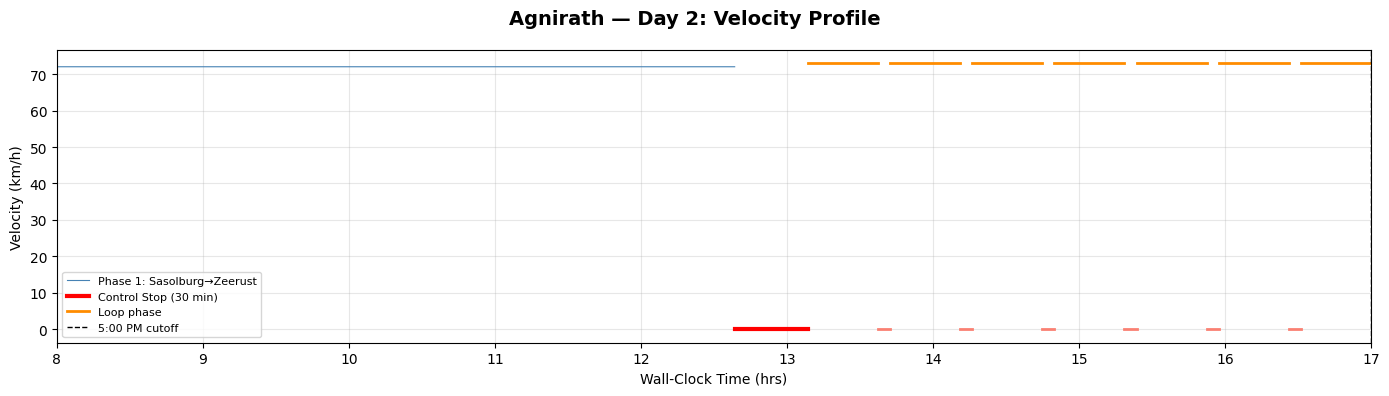

Plot saved as velocity_profile.png


In [22]:
import matplotlib.pyplot as plt
import numpy as np

# --- Plot 1: Velocity Profile vs Wall-Clock Time ---
fig, ax = plt.subplots(figsize=(14, 4))
fig.suptitle("Agnirath — Day 2: Velocity Profile", fontsize=14, fontweight='bold')

# Phase 1 velocity (convert m/s → km/h, plot against wall-clock time in hrs)
t_phase1_hrs = t_phase1_abs / 3600
ax.plot(t_phase1_hrs, optimal_v * 3.6, color='steelblue', linewidth=0.8, label='Phase 1: Sasolburg→Zeerust')

# Control stop
ax.plot([t_control_start/3600, t_control_end/3600], [0, 0],
         color='red', linewidth=3, label='Control Stop (30 min)')

# Loops
for i, (t_pair, v_loop) in enumerate(zip(loop_t_list, loop_v_list)):
    label = 'Loop phase' if i == 0 else ''
    ax.plot([t_pair[0]/3600, t_pair[1]/3600], [v_loop*3.6, v_loop*3.6],
             color='darkorange', linewidth=2, label=label)
    # Inter-loop stops
    if i < best_N - 1:
        ax.plot([t_pair[1]/3600, (t_pair[1]+INTER_LOOP_STOP)/3600], [0, 0],
                 color='salmon', linewidth=2)

ax.axvline(x=RACE_END/3600, color='black', linestyle='--', linewidth=1, label='5:00 PM cutoff')
ax.set_xlabel("Wall-Clock Time (hrs)")
ax.set_ylabel("Velocity (km/h)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim([RACE_START/3600, RACE_END/3600])

plt.tight_layout()
plt.savefig("velocity_profile.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as velocity_profile.png")

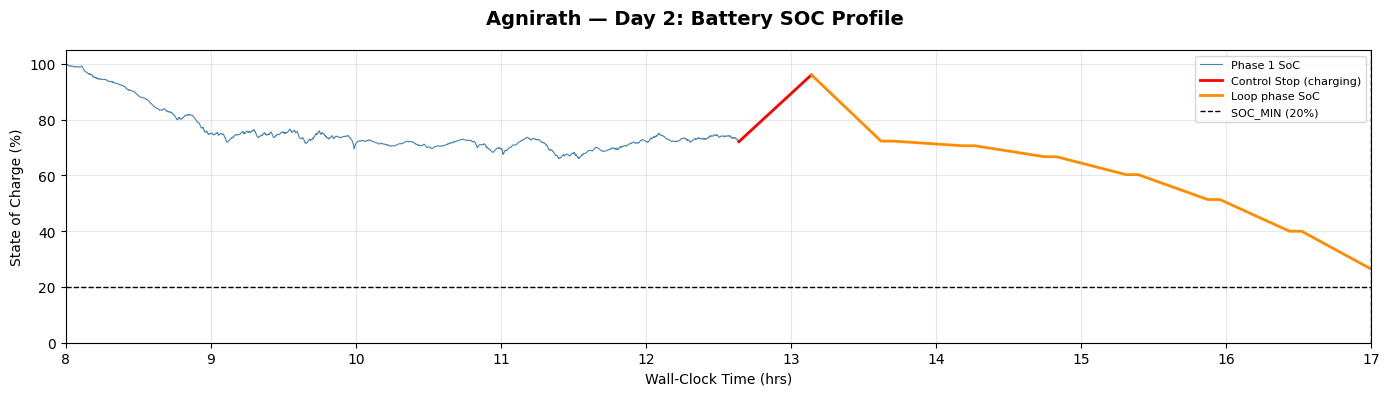

Plot saved as soc_profile.png


In [23]:
import matplotlib.pyplot as plt
import numpy as np

# --- Plot 2: SOC Profile vs Wall-Clock Time ---
fig, ax = plt.subplots(figsize=(14, 4))
fig.suptitle("Agnirath — Day 2: Battery SOC Profile", fontsize=14, fontweight='bold')

# Reconstruct SoC trace for Phase 1
soc_trace_phase1 = [1.0]
SoC_running = 1.0
for i in range(len(optimal_v)):
    SoC_running = new_SoC(
        SoC_running, optimal_v[i], theta[i],
        RACE_START + np.cumsum(ds / optimal_v)[i],
        ds[i] / optimal_v[i], capacity_Wh
    )
    soc_trace_phase1.append(SoC_running)

t_soc_phase1 = np.concatenate([[RACE_START], t_phase1_abs]) / 3600
ax.plot(t_soc_phase1, np.array(soc_trace_phase1) * 100,
         color='steelblue', linewidth=0.8, label='Phase 1 SoC')

# Control stop: SoC charges during 30-min stop (solar still incoming, no motor draw)
# Approximate: sample solar at midpoint of stop
t_stop_mid = (t_control_start + t_control_end) / 2
dt_stop    = CONTROL_STOP
SoC_after_stop = final_soc + (P_solar(t_stop_mid) * dt_stop / 3600) / capacity_Wh
ax.plot([t_control_start/3600, t_control_end/3600],
         [final_soc*100, SoC_after_stop*100],
         color='red', linewidth=2, label='Control Stop (charging)')

# Loop SoC
t_loop_soc_pts = [t_control_end / 3600]
soc_loop_pts   = [SoC_after_stop * 100]
for i, (t_pair, soc_val) in enumerate(zip(loop_t_list, loop_soc_list)):
    t_loop_soc_pts.append(t_pair[1] / 3600)
    soc_loop_pts.append(soc_val * 100)
    # stop between loops: solar charges slightly
    if i < best_N - 1:
        t_stop_mid_loop = (t_pair[1] + INTER_LOOP_STOP / 2) / 3600
        # small SoC bump — approximate as constant for plot clarity
        t_loop_soc_pts.append((t_pair[1] + INTER_LOOP_STOP) / 3600)
        soc_loop_pts.append(soc_val * 100)  # conservative: ignore tiny solar gain

ax.plot(t_loop_soc_pts, soc_loop_pts, color='darkorange', linewidth=2, label='Loop phase SoC')
ax.axhline(y=SOC_MIN*100, color='black', linestyle='--', linewidth=1, label='SOC_MIN (20%)')
ax.axvline(x=RACE_END/3600, color='black', linestyle='--', linewidth=1)
ax.set_xlabel("Wall-Clock Time (hrs)")
ax.set_ylabel("State of Charge (%)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xlim([RACE_START/3600, RACE_END/3600])
ax.set_ylim([0, 105])

plt.tight_layout()
plt.savefig("soc_profile.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as soc_profile.png")